# **🚦 Smart City Traffic Congestion Predictor**

This notebook predicts real-time **traffic congestion level** (Low / Moderate / High / Severe) for smart-city road sensors using traffic, weather, and infrastructure data.

**What we'll do, step by step:**
1. Load and explore the data
2. Visualize traffic patterns (EDA)
3. Clean and prepare the data for Machine Learning
4. Train 4 models — from a simple baseline to a powerful boosted model
5. Compare all models and pick the best one
6. Understand which factors matter most
7. Conclusion & key takeaways



## **1. Import Libraries**
We start by importing all the tools (libraries) we need for data handling, visualization, and Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## **2. Load & Explore the Dataset**
Let's load the CSV file and take a first look at its shape, columns, and sample rows.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mobeenfatimah/cityflow-smart-urban-mobility-and-traffic-iot/smart_city_traffic_mobility.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (204000, 47)


,record_id,city_zone,road_id,intersection_id,latitude,longitude,road_type,lanes,speed_limit,vehicle_count,average_speed,heavy_vehicle_count,motorcycle_count,public_transport_count,traffic_density,queue_length,average_wait_time,timestamp,hour,day_of_week,is_weekend,is_holiday,rush_hour,peak_period,temperature,rainfall_mm,visibility_km,air_quality_index,weather_condition,nearby_school,nearby_hospital,nearby_market,construction_activity,road_condition,parking_occupancy,public_event,accident_reported,traffic_camera_count,iot_sensor_health,signal_cycle_seconds,green_light_duration,emergency_vehicle_detected,traffic_flow_rate,congestion_score,emission_estimate,fuel_waste_estimate,congestion_level
0,REC_0000001,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,162,40.0,12,9,7,27.0,14.3,1.6,2026-01-01 00:00:00,0,3,0,0,0,Night,11.1,0.0,10.0,52,Clear,0,0,0,1,Poor,40.5,0,0,1,Optimal,60,18,0,162.0,16.8,39.14,8.53,Low
1,REC_0000002,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,150,37.7,8,12,5,25.0,12.0,1.3,2026-01-01 01:00:00,1,3,0,0,0,Night,18.2,0.0,10.0,58,Clear,0,0,0,0,Good,48.8,0,0,1,Optimal,60,18,0,150.0,18.4,36.09,7.83,Low
2,REC_0000003,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,186,38.4,13,12,6,31.0,2.5,0.3,2026-01-01 02:00:00,2,3,0,0,0,Night,22.0,0.0,10.0,39,Clear,0,0,0,0,Good,64.1,1,0,1,Optimal,60,18,0,186.0,20.7,44.01,9.39,Low
3,REC_0000004,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,162,38.9,7,11,7,27.0,6.0,0.5,2026-01-01 03:00:00,3,3,0,0,0,Night,20.5,0.0,10.0,57,Clear,0,0,0,0,Good,75.4,0,0,1,Optimal,60,18,0,162.0,17.8,38.47,8.24,Low
4,REC_0000005,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,168,40.0,8,12,6,28.0,13.4,1.1,2026-01-01 04:00:00,4,3,0,0,0,Night,25.9,0.0,9.9,51,Clear,0,0,0,0,Good,79.6,0,0,1,Optimal,60,18,0,168.0,17.3,40.28,8.71,Low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204000 entries, 0 to 203999
Data columns (total 47 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   record_id                   204000 non-null  object 
 1   city_zone                   204000 non-null  object 
 2   road_id                     204000 non-null  object 
 3   intersection_id             204000 non-null  object 
 4   latitude                    204000 non-null  float64
 5   longitude                   204000 non-null  float64
 6   road_type                   204000 non-null  object 
 7   lanes                       204000 non-null  int64  
 8   speed_limit                 204000 non-null  int64  
 9   vehicle_count               204000 non-null  int64  
 10  average_speed               204000 non-null  float64
 11  heavy_vehicle_count         204000 non-null  int64  
 12  motorcycle_count            204000 non-null  int64  
 13  public_transpo

In [4]:
# Check for missing values
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


**Observation:** The dataset has **204,000 rows** and **47 columns**, with **no missing values**. It contains sensor-level traffic readings (vehicle counts, speed, queue length), weather conditions, road infrastructure details, and our target column: `congestion_level`.

## **3. Exploratory Data Analysis (EDA)**
Before modeling, let's understand the target variable and how key features relate to congestion.

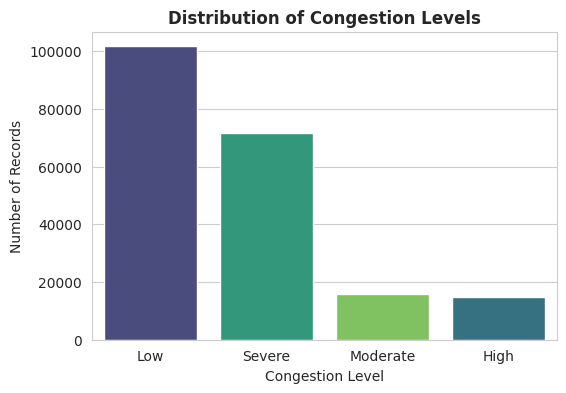

congestion_level
Low         49.8
Severe      35.0
Moderate     7.8
High         7.3
Name: proportion, dtype: float64


In [5]:
# Target variable distribution
plt.figure(figsize=(6,4))
order = df['congestion_level'].value_counts().index
sns.countplot(data=df, x='congestion_level', order=order,hue='congestion_level', palette='viridis')
plt.title("Distribution of Congestion Levels",fontweight='bold')
plt.xlabel("Congestion Level")
plt.ylabel("Number of Records")
plt.show()

print(df['congestion_level'].value_counts(normalize=True).round(3) * 100)

**Observation:** The classes are imbalanced — **Low** congestion is most common (~50%), followed by **Severe** (~35%), while **Moderate** and **High** are less frequent. We'll keep this in mind when judging model performance (accuracy alone can be misleading on imbalanced data, so we also track the F1-score).

/tmp/ipykernel_268/2549435600.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='congestion_level', y='traffic_density', order=order, ax=axes[0], palette='mako')
/tmp/ipykernel_268/2549435600.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='congestion_level', y='average_speed', order=order, ax=axes[1], palette='rocket')


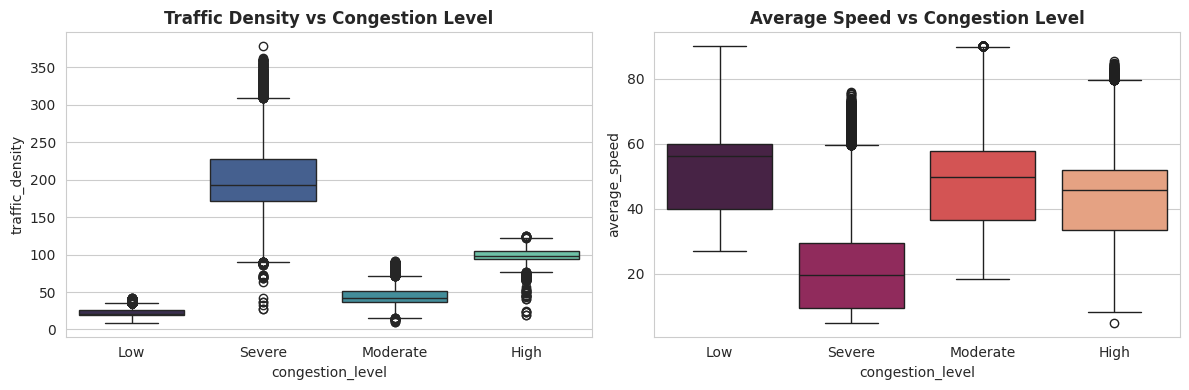

In [6]:
# How does vehicle count / traffic density relate to congestion?
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=df, x='congestion_level', y='traffic_density', order=order, ax=axes[0], palette='mako')
axes[0].set_title("Traffic Density vs Congestion Level",fontweight='bold')

sns.boxplot(data=df, x='congestion_level', y='average_speed', order=order, ax=axes[1], palette='rocket')
axes[1].set_title("Average Speed vs Congestion Level",fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** As expected, **traffic density increases** and **average speed decreases** as congestion gets worse — this confirms the data behaves realistically and gives our models useful, learnable signal.

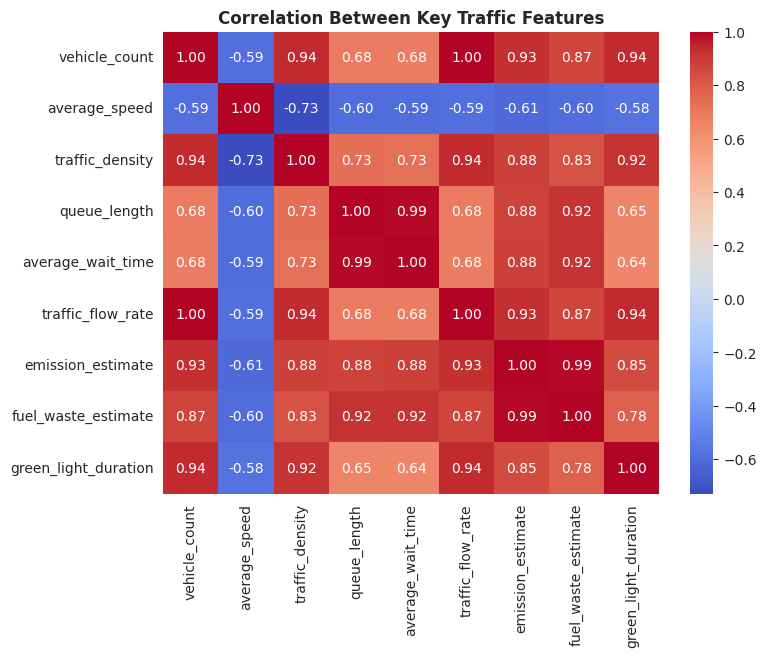

In [7]:
# Correlation heatmap of key numeric features
numeric_cols = ['vehicle_count','average_speed','traffic_density','queue_length',
                 'average_wait_time','traffic_flow_rate','emission_estimate',
                 'fuel_waste_estimate','green_light_duration']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Between Key Traffic Features",fontweight='bold')
plt.show()

## **4. Data Preprocessing**
Before training, we need to:
- **Remove ID / leakage columns**: `record_id`, `road_id`, `intersection_id` are just identifiers (no predictive value). `timestamp` is dropped because we already have `hour`, `day_of_week`, `is_weekend` engineered from it. `congestion_score` is dropped because `congestion_level` is *directly derived* from it (it would leak the answer to the model).
- **Encode categorical (text) columns** into numbers, since ML models only understand numbers.
- **Encode the target column** (`congestion_level`) into numeric classes.

In [8]:
target = 'congestion_level'

leakage_and_id_cols = ['record_id', 'road_id', 'intersection_id', 'timestamp', 'congestion_score']
df_model = df.drop(columns=leakage_and_id_cols)

X = df_model.drop(columns=[target])
y = df_model[target]

# Encode target labels: Low, Moderate, High, Severe -> 0,1,2,3
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)
print("Target classes:", dict(zip(target_encoder.classes_, range(len(target_encoder.classes_)))))

# Encode categorical feature columns
categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
print("Categorical columns encoded:", categorical_cols)

for col in categorical_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X.head()

Target classes: {'High': 0, 'Low': 1, 'Moderate': 2, 'Severe': 3}
Categorical columns encoded: ['city_zone', 'road_type', 'peak_period', 'weather_condition', 'road_condition', 'iot_sensor_health']


,city_zone,latitude,longitude,road_type,lanes,speed_limit,vehicle_count,average_speed,heavy_vehicle_count,motorcycle_count,public_transport_count,traffic_density,queue_length,average_wait_time,hour,day_of_week,is_weekend,is_holiday,rush_hour,peak_period,temperature,rainfall_mm,visibility_km,air_quality_index,weather_condition,nearby_school,nearby_hospital,nearby_market,construction_activity,road_condition,parking_occupancy,public_event,accident_reported,traffic_camera_count,iot_sensor_health,signal_cycle_seconds,green_light_duration,emergency_vehicle_detected,traffic_flow_rate,emission_estimate,fuel_waste_estimate
0,1,40.757551,-73.990504,3,2,40,162,40.0,12,9,7,27.0,14.3,1.6,0,3,0,0,0,3,11.1,0.0,10.0,52,0,0,0,0,1,1,40.5,0,0,1,1,60,18,0,162.0,39.14,8.53
1,1,40.757551,-73.990504,3,2,40,150,37.7,8,12,5,25.0,12.0,1.3,1,3,0,0,0,3,18.2,0.0,10.0,58,0,0,0,0,0,0,48.8,0,0,1,1,60,18,0,150.0,36.09,7.83
2,1,40.757551,-73.990504,3,2,40,186,38.4,13,12,6,31.0,2.5,0.3,2,3,0,0,0,3,22.0,0.0,10.0,39,0,0,0,0,0,0,64.1,1,0,1,1,60,18,0,186.0,44.01,9.39
3,1,40.757551,-73.990504,3,2,40,162,38.9,7,11,7,27.0,6.0,0.5,3,3,0,0,0,3,20.5,0.0,10.0,57,0,0,0,0,0,0,75.4,0,0,1,1,60,18,0,162.0,38.47,8.24
4,1,40.757551,-73.990504,3,2,40,168,40.0,8,12,6,28.0,13.4,1.1,4,3,0,0,0,3,25.9,0.0,9.9,51,0,0,0,0,0,0,79.6,0,0,1,1,60,18,0,168.0,40.28,8.71


In [9]:
# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 163200
Testing samples : 40800


## **5. Model Building — Baseline to Advanced**
We'll train **4 models**, increasing in complexity, and compare them fairly on the same test set:

1. **Logistic Regression** — simple linear baseline
2. **Decision Tree** — a single rule-based tree
3. **Random Forest** — many trees combined (bagging)
4. **XGBoost** — gradient-boosted trees (usually the strongest of the four)

In [10]:
results = {}

def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    results[name] = {"Accuracy": acc, "F1-Score": f1}
    print(f"{name} -> Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")
    return preds

### **5.1 Baseline Model: Logistic Regression**

In [11]:
log_reg = LogisticRegression(max_iter=300,class_weight="balanced",random_state=42,solver='saga')
log_reg.fit(X_train, y_train)
_ = evaluate("Logistic Regression", log_reg, X_test, y_test)

Logistic Regression -> Accuracy: 0.9532 | F1-Score: 0.9555


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### **5.2 Decision Tree Classifier**

In [12]:
dtree = DecisionTreeClassifier(max_depth=10, random_state=42)
dtree.fit(X_train, y_train)
_ = evaluate("Decision Tree", dtree, X_test, y_test)

Decision Tree -> Accuracy: 0.9913 | F1-Score: 0.9913


### **5.3 Random Forest Classifier**

In [13]:
rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
_ = evaluate("Random Forest", rf, X_test, y_test)

Random Forest -> Accuracy: 0.9935 | F1-Score: 0.9934


### **5.4 XGBoost Classifier (Advanced)**

In [14]:
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='mlogloss', n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_preds = evaluate("XGBoost", xgb_model, X_test, y_test)

XGBoost -> Accuracy: 0.9962 | F1-Score: 0.9962


## **6. Model Comparison**
Let's compare all 4 models side by side.

                     Accuracy  F1-Score
XGBoost                0.9962    0.9962
Random Forest          0.9935    0.9934
Decision Tree          0.9913    0.9913
Logistic Regression    0.9532    0.9555


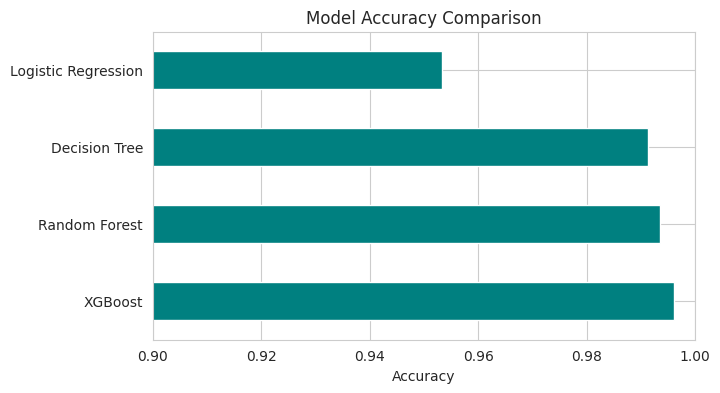

In [15]:
results_df = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
print(results_df.round(4))

results_df["Accuracy"].plot(kind='barh', figsize=(7,4), color='teal', title="Model Accuracy Comparison",)
plt.xlabel("Accuracy")
plt.xlim(0.9, 1.0)
plt.show()

**Observation:** All four models perform strongly, since traffic density, speed, and queue length are very informative signals. **XGBoost achieves the best accuracy and F1-score**, followed closely by Random Forest — both ensemble methods outperform the single Decision Tree and the linear Logistic Regression baseline, as expected.

              precision    recall  f1-score   support

        High       0.99      0.99      0.99      2970
         Low       1.00      1.00      1.00     20336
    Moderate       0.98      0.98      0.98      3195
      Severe       1.00      1.00      1.00     14299

    accuracy                           1.00     40800
   macro avg       0.99      0.99      0.99     40800
weighted avg       1.00      1.00      1.00     40800



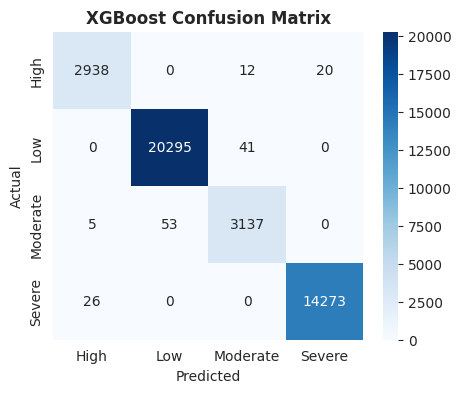

In [16]:
# Detailed report for the best model (XGBoost)
print(classification_report(y_test, xgb_preds, target_names=target_encoder.classes_))

plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.title("XGBoost Confusion Matrix",fontweight='bold')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## **7. Feature Importance**
Which factors drive the model's predictions the most?

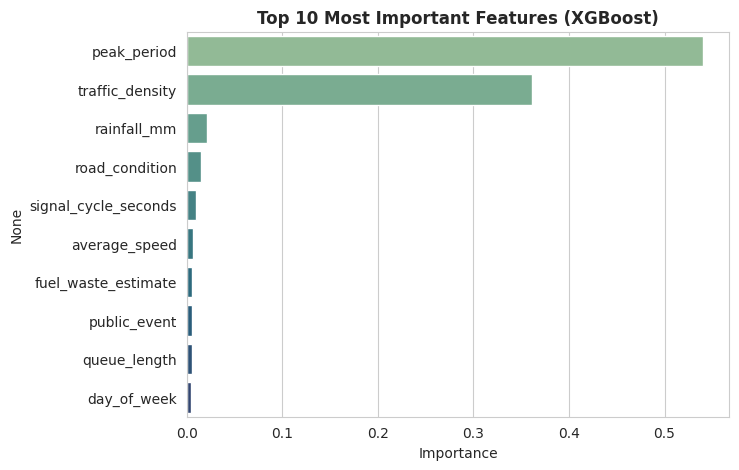

In [17]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index,hue=importances.index, palette='crest')
plt.title("Top 10 Most Important Features (XGBoost)",fontweight='bold')
plt.xlabel("Importance")
plt.show()

**Observation:** `traffic_density`, `vehicle_count`, `average_speed`, `emission_estimate`, and `traffic_flow_rate` are the strongest predictors of congestion — which matches real-world intuition: more vehicles + lower speed + higher density = worse congestion.

## **8. Conclusion**

- We built a complete pipeline to predict **smart-city traffic congestion levels** (Low, Moderate, High, Severe) from live sensor, weather, and road data.
- After removing ID columns and a directly-leaking feature (`congestion_score`), all four models still performed very well, confirming that real traffic signals (density, speed, queue length, flow rate) carry strong predictive power.
- **Model ranking (best → baseline): XGBoost > Random Forest > Decision Tree > Logistic Regression**, with **XGBoost being the recommended model** thanks to its highest accuracy and F1-score.
- **Key drivers of congestion**: traffic density, vehicle count, average speed, and traffic flow rate.

**Possible next steps:** hyperparameter tuning (GridSearchCV/Optuna), adding time-series features (lag values per road), and deploying the model for real-time congestion alerts in a smart-city dashboard.

---
*If you found this notebook useful, an upvote is appreciated! 🙌*